# Module 1 (Foundations) — Post-Lecture Coding Questions

## Instructions
- Use Python 3.10+. You may use `random`, `math`, and `statistics`.
- Keep your code readable (functions, docstrings, comments).
- For questions involving randomness, run multiple episodes and report summary statistics.
- You may submit a single `.py` file or a `.ipynb` notebook.

## Shared Toy MDP (used in all questions)

We use an episodic, deterministic Markov Decision Process with:
- **States:** {A, B, T} where T is terminal.
- **Actions:** {0, 1}.
- **Discount factor:** γ = 0.9.

### Dynamics and Rewards

| State | Action | Next State | Reward |
|-------|--------|------------|--------|
| A     | 0      | B          | +1     |
| A     | 1      | T          | 0      |
| B     | 0      | A          | 0      |
| B     | 1      | T          | +2     |

### Stochastic Policy π (used in Q1–Q2)
- At A: π(0|A) = 0.7, π(1|A) = 0.3.
- At B: π(0|B) = 0.4, π(1|B) = 0.6.

### Discounted Return

For an episode that generates rewards $r_1, r_2, \ldots, r_T$, the discounted return from time $t = 0$ is:

$$G_0 = \sum_{k=0}^{T-1} \gamma^k r_{k+1}$$

## Question 1 — Simulate Episodes and Compute Returns (Monte Carlo)

**Goal:** Practice generating trajectory data and computing discounted returns.

### Tasks
1. Implement the environment step function: $(s_{t+1},\ r_{t+1},\ \text{done}) = \text{step}(s_t, a_t)$.
2. Implement the given stochastic policy $\pi(a|s)$ and sample actions from it.
3. Simulate $N$ episodes starting from $s_0 = A$.
4. Compute $G_0$ for each episode and report:
   - the mean return,
   - the standard deviation of returns.

### Hints
- Store each transition as a tuple $(s, a, r, s', \text{done})$ (useful later).
- The reward is received after taking an action.
- Discounted return in Python:

$$G_0 = \sum_{t=0}^{T-1} \gamma^t\, r_{t+1}$$

#My Solution:

In [120]:
import random
from statistics import mean, pstdev

# --- Constants ---
GAMMA = 0.5          # Discount factor
N_EPISODES = 1000  # Number of episodes to simulate
START_STATE = "A"    # Initial state

# Transition dynamics: (state, action) -> (next_state, reward, done)
TRANSITIONS = {
    ("A", 0): ("B", 1.0, False),
    ("A", 1): ("T", 0.0, True),
    ("B", 0): ("A", 0.0, False),
    ("B", 1): ("T", 2.0, True),
}

# --- Task 1: Environment step function ---
def step(state, action):
    # Look up the transition for the current (state, action) pair.
    # If not found (e.g. terminal state), default to staying terminal with no reward.
    return TRANSITIONS.get((state, action), ("T", 0.0, True))

# Example:
print("step('A', 0) ->", step("A", 0))  # Expected: ('B', 1.0, False)
print("step('B', 1) ->", step("B", 1))  # Expected: ('T', 2.0, True)
print("step('A', 1) ->", step("A", 1))  # Expected: ('T', 0.0, True)

step('A', 0) -> ('B', 1.0, False)
step('B', 1) -> ('T', 2.0, True)
step('A', 1) -> ('T', 0.0, True)


In [121]:
# Stochastic policy: state -> {action: probability}
POLICY = {
    "A": {0: 0.7, 1: 0.3},
    "B": {0: 0.4, 1: 0.6},
}

# --- Task 2: Stochastic policy and action sampling ---
def policy_probs(state):
    # Returns an empty dict for terminal states that have no defined policy.
    return POLICY.get(state, {})

# Example:
print("policy_probs('A') ->", policy_probs("A"))  # Expected: {0: 0.7, 1: 0.3}
print("policy_probs('B') ->", policy_probs("B"))  # Expected: {0: 0.4, 1: 0.6}
print("policy_probs('T') ->", policy_probs("T"))  # Expected: {}

def sample_action(state):
    probs = policy_probs(state)
    actions = list(probs.keys())
    weights = list(probs.values())
    # Randomly pick one action weighted by its probability.
    return random.choices(actions, weights=weights)[0]

# Example: sample 10 actions from state A (should be mostly 0s due to 0.7 probability)
samples = [sample_action("A") for _ in range(10)]
print("sample_action('A') x10 ->", samples)

policy_probs('A') -> {0: 0.7, 1: 0.3}
policy_probs('B') -> {0: 0.4, 1: 0.6}
policy_probs('T') -> {}
sample_action('A') x10 -> [0, 1, 0, 0, 0, 0, 1, 0, 0, 0]


In [122]:
# --- Task 3: Simulate N episodes ---
def simulate_episode(start_state=START_STATE):
    state = start_state
    trajectory = []  # List of (s, a, r, s', done) tuples
    t = 0            # Time step counter used for discounting
    G0 = 0.0         # Accumulated discounted return

    while True:
        action = sample_action(state)                                      # Sample action from policy
        next_state, reward, done = step(state, action)                     # Execute action in environment
        trajectory.append((state, action, reward, next_state, done))       # Store transition
        G0 += (GAMMA ** t) * reward                                        # Accumulate discounted reward
        t += 1

        if done:  # Stop when terminal state is reached
            break
        state = next_state

    return trajectory, G0

# Example: print one episode's trajectory and return
example_trajectory, example_G0 = simulate_episode()
print("Example episode (s, a, r, s', done):")
for transition in example_trajectory:
    print(" ", transition)
print(f"Discounted return G0: {example_G0:.4f}")

# Run N episodes and collect returns
returns = []
trajectories = []
for episode in range(N_EPISODES):
    _trajectory, G0 = simulate_episode()
    trajectories.append(_trajectory)
    returns.append(G0)

Example episode (s, a, r, s', done):
  ('A', 0, 1.0, 'B', False)
  ('B', 0, 0.0, 'A', False)
  ('A', 1, 0.0, 'T', True)
Discounted return G0: 1.0000


In [123]:
# --- Task 4: Compute and report G0 statistics ---
mean_return = mean(returns)
std_return  = pstdev(returns)

print(f"Episodes simulated: {N_EPISODES}")
print(f"Mean return:        {mean_return:.4f}")
print(f"Std deviation:      {std_return:.4f}")

Episodes simulated: 1000
Mean return:        1.1813
Std deviation:      0.8589


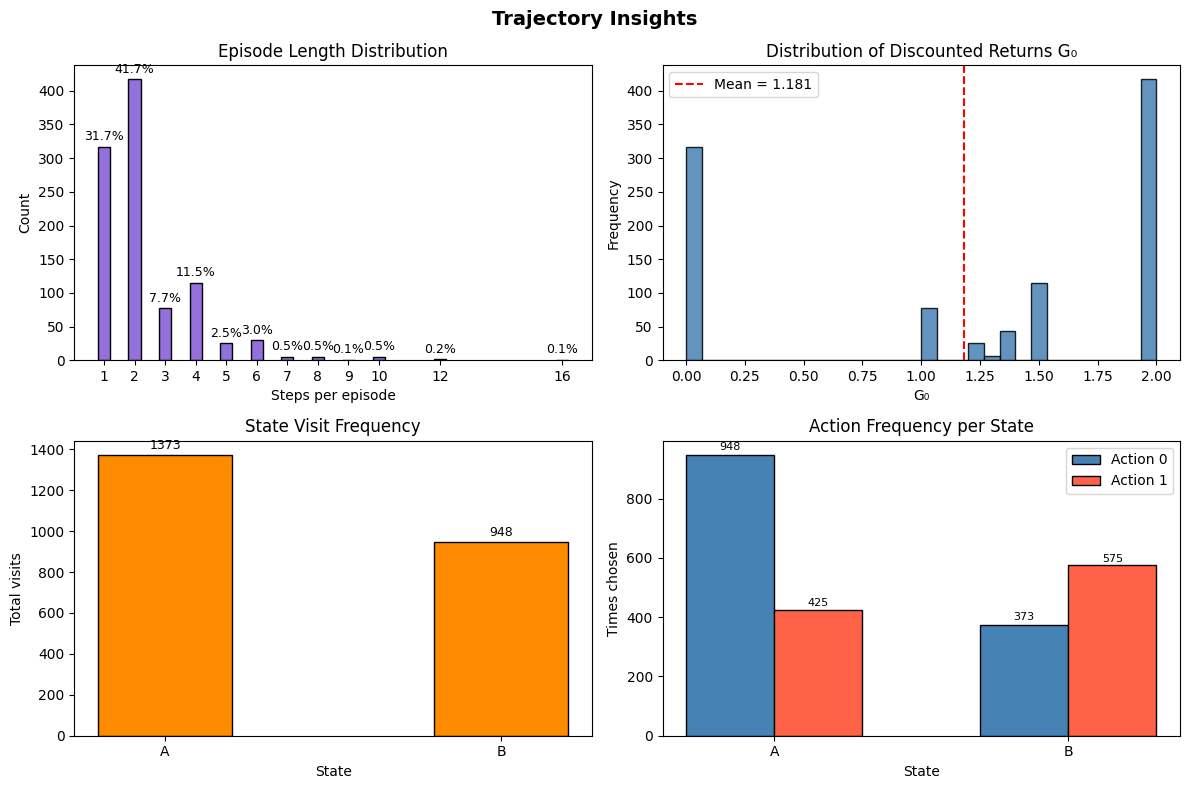

In [124]:
import matplotlib.pyplot as plt
from collections import defaultdict

# --- Derive stats from trajectories ---
ep_lengths    = [len(traj) for traj in trajectories]
state_visits  = defaultdict(int)
action_freq   = defaultdict(lambda: defaultdict(int))
ep_returns    = returns  # already computed in cell 6

for traj in trajectories:
    for (s, a, r, s_next, done) in traj:
        state_visits[s] += 1
        action_freq[s][a] += 1

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Trajectory Insights", fontsize=14, fontweight="bold")

# Panel 1: Episode length distribution
ax1 = axes[0, 0]
unique_lens = sorted(set(ep_lengths))
len_counts  = [ep_lengths.count(l) for l in unique_lens]
ax1.bar(unique_lens, len_counts, color="mediumpurple", edgecolor="black", width=0.4)
ax1.set_title("Episode Length Distribution")
ax1.set_xlabel("Steps per episode")
ax1.set_ylabel("Count")
ax1.set_xticks(unique_lens)
for x, y in zip(unique_lens, len_counts):
    ax1.text(x, y + N_EPISODES * 0.005, f"{y/N_EPISODES*100:.1f}%",
             ha="center", va="bottom", fontsize=9)

# Panel 2: Return distribution (histogram)
ax2 = axes[0, 1]
ax2.hist(ep_returns, bins=30, color="steelblue", edgecolor="black", alpha=0.85)
ax2.axvline(mean(ep_returns), color="red", linestyle="--", linewidth=1.5,
            label=f"Mean = {mean(ep_returns):.3f}")
ax2.set_title("Distribution of Discounted Returns G₀")
ax2.set_xlabel("G₀")
ax2.set_ylabel("Frequency")
ax2.legend()

# Panel 3: State visit frequency
ax3 = axes[1, 0]
states = sorted(state_visits.keys())
counts = [state_visits[s] for s in states]
ax3.bar(states, counts, color="darkorange", edgecolor="black", width=0.4)
ax3.set_title("State Visit Frequency")
ax3.set_xlabel("State")
ax3.set_ylabel("Total visits")
for x, y in zip(states, counts):
    ax3.text(x, y + max(counts) * 0.01, str(y), ha="center", va="bottom", fontsize=9)

# Panel 4: Action frequency per non-terminal state
ax4 = axes[1, 1]
nonstates = [s for s in sorted(action_freq.keys()) if s != "T"]
x_pos = range(len(nonstates))
w = 0.3
for offset, (act, color) in enumerate([(0, "steelblue"), (1, "tomato")]):
    freqs = [action_freq[s][act] for s in nonstates]
    rects = ax4.bar([x + offset * w for x in x_pos], freqs,
                    width=w, color=color, edgecolor="black", label=f"Action {act}")
    for rect, v in zip(rects, freqs):
        ax4.text(rect.get_x() + rect.get_width() / 2,
                 rect.get_height() + max(freqs) * 0.01,
                 str(v), ha="center", va="bottom", fontsize=8)
ax4.set_title("Action Frequency per State")
ax4.set_xlabel("State")
ax4.set_ylabel("Times chosen")
ax4.set_xticks([x + w / 2 for x in x_pos])
ax4.set_xticklabels(nonstates)
ax4.legend()

plt.tight_layout()
plt.show()


Converged at episode 28  (max ΔQ = 8.31e-03 < 1e-02)
------------------------------------------------------------------------
     Episode      Q(A,0)      Q(A,1)      Q(B,0)      Q(B,1)      max ΔQ
------------------------------------------------------------------------
           1         2.0         0.0         1.0         2.0         2.0
           2        1.75         0.0      0.8359         2.0        0.25
           3      1.8333         0.0      0.8906         2.0    0.083333
           4       1.875         0.0       0.793         2.0    0.097656
           5         1.8         0.0      0.8344         2.0       0.075
           6      1.7292         0.0      0.6953         2.0    0.139062
           7       1.625         0.0      0.7388         2.0    0.104167
           8      1.6719         0.0      0.7715         2.0    0.046875
           9      1.7083         0.0      0.7969         2.0    0.036458
          10      1.7375         0.0      0.7922         2.0    0.02916

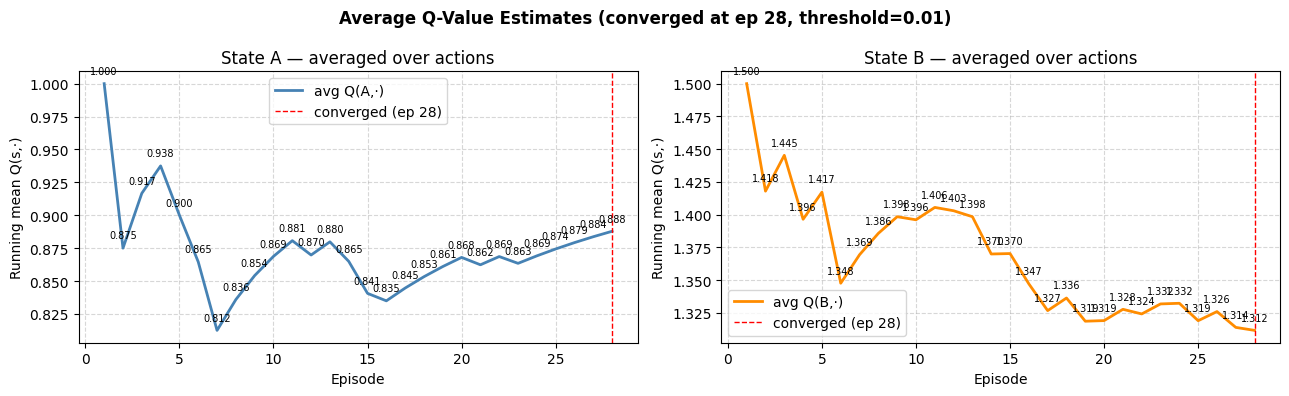

In [125]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict

# ── Parameters ────────────────────────────────────────────────────────────────
MAX_EPISODES = 10_000   # hard cap — never run more than this
CONV_THRESHOLD = 1e-2  # stop when max Q-update across all (s,a) < this value

sa_pairs  = [("A", 0), ("A", 1), ("B", 0), ("B", 1)]
q_running = defaultdict(list)   # accumulated returns per (s,a)
table_rows = []                  # one row per episode

prev_q = {k: 0.0 for k in sa_pairs}   # previous running-mean estimates

for ep_idx in range(1, MAX_EPISODES + 1):
    # Force each (s,a) once, then follow π
    for (ss, sa) in sa_pairs:
        ns, r0, done_sa = step(ss, sa)
        G = r0
        t = 1
        st = ns
        while not done_sa:
            act = sample_action(st)
            ns2, r2, done_sa = step(st, act)
            G += (GAMMA ** t) * r2
            t += 1
            st = ns2
        q_running[(ss, sa)].append(G)

    curr_q = {k: mean(q_running[k]) for k in sa_pairs}
    max_delta = max(abs(curr_q[k] - prev_q[k]) for k in sa_pairs)

    row = [ep_idx] + [round(curr_q[k], 4) for k in sa_pairs] + [round(max_delta, 6)]
    table_rows.append(row)

    prev_q = curr_q

    if max_delta < CONV_THRESHOLD:
        print(f"Converged at episode {ep_idx}  (max ΔQ = {max_delta:.2e} < {CONV_THRESHOLD:.0e})")
        break
else:
    print(f"Reached MAX_EPISODES={MAX_EPISODES} without converging (last max ΔQ = {max_delta:.2e})")

n_eps = len(table_rows)

# ── Print table ───────────────────────────────────────────────────────────────
col_headers = ["Episode", "Q(A,0)", "Q(A,1)", "Q(B,0)", "Q(B,1)", "max ΔQ"]
col_w = 12
header = "".join(h.rjust(col_w) for h in col_headers)
sep    = "-" * len(header)
print(sep)
print(header)
print(sep)
for row in table_rows:
    print("".join(str(v).rjust(col_w) for v in row))
print(sep)

# ── Plot: Q-value convergence — one averaged line per state ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"Average Q-Value Estimates (converged at ep {n_eps}, threshold={CONV_THRESHOLD})",
             fontsize=12, fontweight="bold")

colors_map = {"A": "steelblue", "B": "darkorange"}
episodes   = [row[0] for row in table_rows]

for ax, state in zip(axes, ["A", "B"]):
    avg_vals = [
        mean([mean(q_running[(state, a)][:i]) for a in [0, 1]])
        for i in range(1, n_eps + 1)
    ]
    ax.plot(episodes, avg_vals, color=colors_map[state], linewidth=2,
            label=f"avg Q({state},·)")
    # Only annotate if few enough points to read
    if n_eps <= 50:
        for x, y in zip(episodes, avg_vals):
            ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                        xytext=(0, 7), ha="center", fontsize=7)
    ax.axvline(n_eps, color="red", linestyle="--", linewidth=1,
               label=f"converged (ep {n_eps})")
    ax.set_title(f"State {state} — averaged over actions")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Running mean Q(s,·)")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
